# 10 - Covered Call Backtesting

Simulates covered call strategies using actual options data. Compares
model-guided strike selection against static benchmarks (always-ATM,
always-OTM5, always-OTM10).

**Metrics**: Sharpe ratio, max drawdown, win rate, cumulative returns
**Output**: `backtest_results.csv`, equity curve figures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

PROCESSED = Path('../data/processed')
FIGURES = Path('../reports/figures')
SEED = 42
np.random.seed(SEED)

UNIVERSE = ['AAPL', 'AMZN', 'AVGO', 'GOOG', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA', 'WMT']
label_names = {0: 'ATM', 1: 'OTM5', 2: 'OTM10'}
moneyness_map = {'ATM': 0, 'OTM5': 1, 'OTM10': 2}

## 1. Load Data

In [2]:
# Options data
options = pd.read_parquet(PROCESSED / 'options_clean.parquet')
calls = options[(options['call_put'] == 'CALL') & (options['symbol'].isin(UNIVERSE))].copy()
calls['expiration'] = pd.to_datetime(calls['expiration'])
calls['trade_date'] = pd.to_datetime(calls['trade_date'])
calls['dte'] = (calls['expiration'] - calls['trade_date']).dt.days

# Stock prices
daily_prices = pd.read_parquet(PROCESSED / 'daily_clean.parquet')
daily_prices = daily_prices[daily_prices['symbol'].isin(UNIVERSE)].copy()
daily_prices['date'] = pd.to_datetime(daily_prices['date'])
prices = daily_prices[['symbol', 'date', 'adjusted_close']].rename(
    columns={'adjusted_close': 'price'})

# Model recommendations from notebook 09
recs = pd.read_csv(PROCESSED / 'strike_recommendations.csv')
recs['date'] = pd.to_datetime(recs['date'])
recs['year_month'] = recs['date'].dt.to_period('M')

# Monthly labels (true best)
monthly_labels = pd.read_parquet(PROCESSED / 'monthly_labels.parquet')

print(f"Call options: {len(calls):,}")
print(f"Daily prices: {len(daily_prices):,}")
print(f"Model recommendations: {len(recs):,}")
print(f"Monthly labels: {len(monthly_labels):,}")

Call options: 560,976
Daily prices: 52,486
Model recommendations: 24,669
Monthly labels: 1,391


## 2. Build Trade Universe

For each (symbol, trade_date), find the best representative call option in each
moneyness bucket (ATM, OTM5, OTM10). Filter to DTE 20-60 and pick the option
closest to the midpoint delta of each bucket.

In [3]:
# Moneyness bucket definitions (same as notebook 05)
bucket_defs = {
    'ATM':   {'delta_lo': 0.45, 'delta_hi': 0.60, 'delta_mid': 0.52},
    'OTM5':  {'delta_lo': 0.30, 'delta_hi': 0.45, 'delta_mid': 0.37},
    'OTM10': {'delta_lo': 0.15, 'delta_hi': 0.30, 'delta_mid': 0.22},
}

# Filter to monthly options with DTE 20-60
trade_calls = calls[(calls['dte'] >= 20) & (calls['dte'] <= 60)].copy()
trade_calls['premium'] = trade_calls['mark'].fillna(
    (trade_calls['bid'] + trade_calls['ask']) / 2)

# Keep only options with positive premium and bid
trade_calls = trade_calls[(trade_calls['premium'] > 0) & (trade_calls['bid'] > 0)].copy()

print(f"Tradeable calls (DTE 20-60, positive premium): {len(trade_calls):,}")

# For each (symbol, trade_date, moneyness_bucket), pick the option closest
# to the midpoint delta
trade_menu = []
for bucket_name, bdef in bucket_defs.items():
    subset = trade_calls[
        (trade_calls['delta'] >= bdef['delta_lo']) &
        (trade_calls['delta'] < bdef['delta_hi'])
    ].copy()
    subset['delta_dist'] = (subset['delta'] - bdef['delta_mid']).abs()

    # Pick closest-to-midpoint per (symbol, trade_date)
    best_idx = subset.groupby(['symbol', 'trade_date'])['delta_dist'].idxmin()
    best = subset.loc[best_idx].copy()
    best['moneyness'] = bucket_name
    trade_menu.append(best)

trade_menu = pd.concat(trade_menu, ignore_index=True)
trade_menu = trade_menu.sort_values(['symbol', 'trade_date', 'moneyness']).reset_index(drop=True)

print(f"Trade menu: {len(trade_menu):,} entries")
print(f"Per bucket: {trade_menu['moneyness'].value_counts().to_dict()}")
print(f"Date range: {trade_menu['trade_date'].min().date()} to {trade_menu['trade_date'].max().date()}")

Tradeable calls (DTE 20-60, positive premium): 260,990
Trade menu: 4,026 entries
Per bucket: {'OTM10': 1357, 'OTM5': 1345, 'ATM': 1324}
Date range: 2008-02-01 to 2025-12-01


## 3. Compute Covered Call Returns

For each option in the trade menu, compute the covered call payoff:
return = (premium + min(exit_price, strike) - entry_price) / entry_price

In [4]:
# Merge entry price (stock price on trade_date)
trade_menu = trade_menu.merge(
    prices.rename(columns={'date': 'trade_date', 'price': 'entry_price'}),
    on=['symbol', 'trade_date'], how='left')

# Merge exit price (stock price on or before expiration)
exit_prices = prices.rename(columns={'date': 'expiration', 'price': 'exit_price'})
result_parts = []
for sym in UNIVERSE:
    left = trade_menu[trade_menu['symbol'] == sym].sort_values('expiration')
    right = exit_prices[exit_prices['symbol'] == sym].sort_values('expiration')
    merged = pd.merge_asof(left, right[['expiration', 'exit_price']],
                           on='expiration', direction='backward')
    result_parts.append(merged)
trade_menu = pd.concat(result_parts, ignore_index=True)

# Compute covered call return
trade_menu['stock_pnl'] = np.minimum(trade_menu['exit_price'], trade_menu['strike']) - trade_menu['entry_price']
trade_menu['total_pnl'] = trade_menu['premium'] + trade_menu['stock_pnl']
trade_menu['cc_return'] = trade_menu['total_pnl'] / trade_menu['entry_price']

# Filter out trades with missing data or extreme outliers
trade_menu = trade_menu.dropna(subset=['entry_price', 'exit_price', 'cc_return'])
trade_menu = trade_menu[
    (trade_menu['cc_return'] > -0.5) & (trade_menu['cc_return'] < 0.5) &
    (trade_menu['entry_price'] > 0)
].copy()

trade_menu['year_month'] = trade_menu['trade_date'].dt.to_period('M')

print(f"Trades with returns: {len(trade_menu):,}")
print(f"Return statistics:")
print(trade_menu.groupby('moneyness')['cc_return'].describe().round(4))

Trades with returns: 3,031
Return statistics:
            count    mean     std     min     25%     50%     75%     max
moneyness                                                                
ATM         759.0  0.1159  0.1529 -0.3106  0.0299  0.0613  0.1695  0.4998
OTM10      1217.0  0.1148  0.1344 -0.4529  0.0244  0.0962  0.1939  0.4980
OTM5       1055.0  0.1563  0.1681 -0.2676  0.0344  0.0949  0.3046  0.4995


## 4. Map Model Recommendations to Monthly Trades

The model produces daily predictions, but trades happen monthly (on options
trade_date). For each (symbol, trade_date), look up the model's recommendation
for that month.

In [5]:
# Get monthly model recommendations: take the mode (most frequent) prediction
# per (symbol, year_month) to get a single monthly recommendation
recs['year_month'] = pd.PeriodIndex(recs['year_month'], freq='M')

monthly_recs = recs.groupby(['symbol', 'year_month']).agg(
    sel_argmax=('sel_argmax', lambda x: x.mode().iloc[0]),
    sel_risk_adjusted=('sel_risk_adjusted', lambda x: x.mode().iloc[0]),
    sel_diversified=('sel_diversified', lambda x: x.mode().iloc[0]),
).reset_index()

# Map numeric to moneyness name
for col in ['sel_argmax', 'sel_risk_adjusted', 'sel_diversified']:
    monthly_recs[col + '_name'] = monthly_recs[col].map(label_names)

# Also get oracle (true best) from monthly_labels
monthly_labels['year_month'] = pd.PeriodIndex(monthly_labels['year_month'], freq='M')
oracle = monthly_labels[['symbol', 'year_month', 'best_moneyness']].copy()
oracle = oracle.rename(columns={'best_moneyness': 'oracle_name'})
oracle['oracle'] = oracle['oracle_name'].map(moneyness_map)

monthly_recs = monthly_recs.merge(oracle, on=['symbol', 'year_month'], how='inner')

print(f"Monthly recommendations: {len(monthly_recs):,}")
print(f"Date range: {monthly_recs['year_month'].min()} to {monthly_recs['year_month'].max()}")

Monthly recommendations: 1,172
Date range: 2014-02 to 2025-12


## 5. Compute Strategy Returns

For each strategy, select the appropriate moneyness bucket per (symbol, month)
and look up the actual covered call return from the trade menu.

In [6]:
# Pivot trade_menu to get return per (symbol, year_month, moneyness)
# Average returns if multiple trades per (symbol, month, bucket)
monthly_returns = trade_menu.groupby(
    ['symbol', 'year_month', 'moneyness'])['cc_return'].mean().reset_index()
monthly_returns_wide = monthly_returns.pivot_table(
    index=['symbol', 'year_month'], columns='moneyness',
    values='cc_return').reset_index()
monthly_returns_wide.columns.name = None

# Rename for clarity
for bucket in ['ATM', 'OTM5', 'OTM10']:
    if bucket in monthly_returns_wide.columns:
        monthly_returns_wide = monthly_returns_wide.rename(
            columns={bucket: f'ret_{bucket}'})

# Merge recommendations with returns
bt = monthly_recs.merge(monthly_returns_wide, on=['symbol', 'year_month'], how='inner')

# Define strategy columns and their corresponding return lookup
strategy_configs = {
    'Always-ATM': ('static', 'ATM'),
    'Always-OTM5': ('static', 'OTM5'),
    'Always-OTM10': ('static', 'OTM10'),
    'Model-Argmax': ('model', 'sel_argmax_name'),
    'Model-Risk-Adj': ('model', 'sel_risk_adjusted_name'),
    'Model-Diversified': ('model', 'sel_diversified_name'),
    'Oracle': ('model', 'oracle_name'),
}

for strat_name, (strat_type, col_or_bucket) in strategy_configs.items():
    if strat_type == 'static':
        bt[strat_name] = bt[f'ret_{col_or_bucket}']
    else:
        # Look up return for the selected bucket
        bt[strat_name] = bt.apply(
            lambda row: row.get(f"ret_{row[col_or_bucket]}", np.nan), axis=1)

# Add random strategy
np.random.seed(SEED)
random_choices = np.random.choice(['ATM', 'OTM5', 'OTM10'], size=len(bt))
bt['Random'] = bt.apply(
    lambda row: row.get(f"ret_{random_choices[row.name]}", np.nan), axis=1)

# Drop rows where any strategy has missing return (missing bucket data)
strat_cols = list(strategy_configs.keys()) + ['Random']
bt = bt.dropna(subset=strat_cols)

print(f"Backtest trades: {len(bt):,}")
print(f"Months covered: {bt['year_month'].nunique()}")
print(f"Tickers per month: {bt.groupby('year_month')['symbol'].nunique().describe().round(1)}")

Backtest trades: 724
Months covered: 128
Tickers per month: count    128.0
mean       5.7
std        2.5
min        2.0
25%        3.8
50%        5.0
75%        8.0
max       10.0
Name: symbol, dtype: float64


## 6. Portfolio-Level Monthly Returns

Equal-weight across all available tickers per month.

In [7]:
# Equal-weight portfolio returns per month
portfolio = bt.groupby('year_month')[strat_cols].mean().reset_index()
portfolio['year_month_ts'] = portfolio['year_month'].dt.to_timestamp()
portfolio = portfolio.sort_values('year_month_ts').reset_index(drop=True)

print(f"Portfolio months: {len(portfolio)}")
print(f"\nMean Monthly Return by Strategy:")
for col in strat_cols:
    print(f"  {col:20s}: {portfolio[col].mean():.4f}")

Portfolio months: 128

Mean Monthly Return by Strategy:
  Always-ATM          : 0.1285
  Always-OTM5         : 0.0831
  Always-OTM10        : 0.0482
  Model-Argmax        : 0.1211
  Model-Risk-Adj      : 0.1216
  Model-Diversified   : 0.1126
  Oracle              : 0.1337
  Random              : 0.0857


## 7. Risk Metrics

In [8]:
def compute_risk_metrics(returns, rf_annual=0.04):
    """Compute risk metrics from a series of monthly returns."""
    n_months = len(returns)
    rf_monthly = (1 + rf_annual) ** (1/12) - 1

    # Annualized return (geometric)
    cum_return = (1 + returns).prod()
    n_years = n_months / 12
    ann_return = cum_return ** (1 / n_years) - 1 if n_years > 0 else 0

    # Annualized volatility
    ann_vol = returns.std() * np.sqrt(12)

    # Sharpe ratio
    excess = returns - rf_monthly
    sharpe = excess.mean() / returns.std() * np.sqrt(12) if returns.std() > 0 else 0

    # Max drawdown from equity curve
    equity = (1 + returns).cumprod()
    rolling_max = equity.cummax()
    drawdown = (equity - rolling_max) / rolling_max
    max_dd = drawdown.min()

    # Calmar ratio
    calmar = ann_return / abs(max_dd) if max_dd != 0 else 0

    # Win rate
    win_rate = (returns > 0).mean()

    # Avg win / avg loss
    wins = returns[returns > 0]
    losses = returns[returns < 0]
    avg_win = wins.mean() if len(wins) > 0 else 0
    avg_loss = losses.mean() if len(losses) > 0 else 0

    return {
        'Ann. Return': ann_return,
        'Ann. Vol': ann_vol,
        'Sharpe': sharpe,
        'Max DD': max_dd,
        'Calmar': calmar,
        'Win Rate': win_rate,
        'Avg Win': avg_win,
        'Avg Loss': avg_loss,
    }

# Compute metrics for all strategies
metrics_rows = []
for col in strat_cols:
    m = compute_risk_metrics(portfolio[col])
    m['Strategy'] = col
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows)
metrics_df = metrics_df[['Strategy', 'Ann. Return', 'Ann. Vol', 'Sharpe',
                          'Max DD', 'Calmar', 'Win Rate', 'Avg Win', 'Avg Loss']]
metrics_df = metrics_df.sort_values('Sharpe', ascending=False).reset_index(drop=True)

print("Risk Metrics Summary (sorted by Sharpe):")
print(metrics_df.round(4).to_string(index=False))

Risk Metrics Summary (sorted by Sharpe):
         Strategy  Ann. Return  Ann. Vol  Sharpe  Max DD  Calmar  Win Rate  Avg Win  Avg Loss
           Oracle       3.3818    0.2687  5.8232 -0.0837 40.4264    0.9766   0.1376   -0.0322
       Always-ATM       3.1393    0.2803  5.3625 -0.0920 34.1059    0.9766   0.1325   -0.0376
   Model-Risk-Adj       2.8424    0.2801  5.0681 -0.1127 25.2303    0.9688   0.1269   -0.0419
     Model-Argmax       2.8240    0.2802  5.0474 -0.1271 22.2112    0.9688   0.1265   -0.0456
Model-Diversified       2.4969    0.2681  4.8955 -0.1381 18.0858    0.9609   0.1189   -0.0422
      Always-OTM5       1.5553    0.2145  4.4645 -0.1222 12.7269    0.9219   0.0926   -0.0292
           Random       1.6232    0.2318  4.2688 -0.1134 14.3173    0.9219   0.0965   -0.0416
     Always-OTM10       0.7314    0.1856  2.9038 -0.1701  4.2996    0.8125   0.0679   -0.0371


## 8. Equity Curves

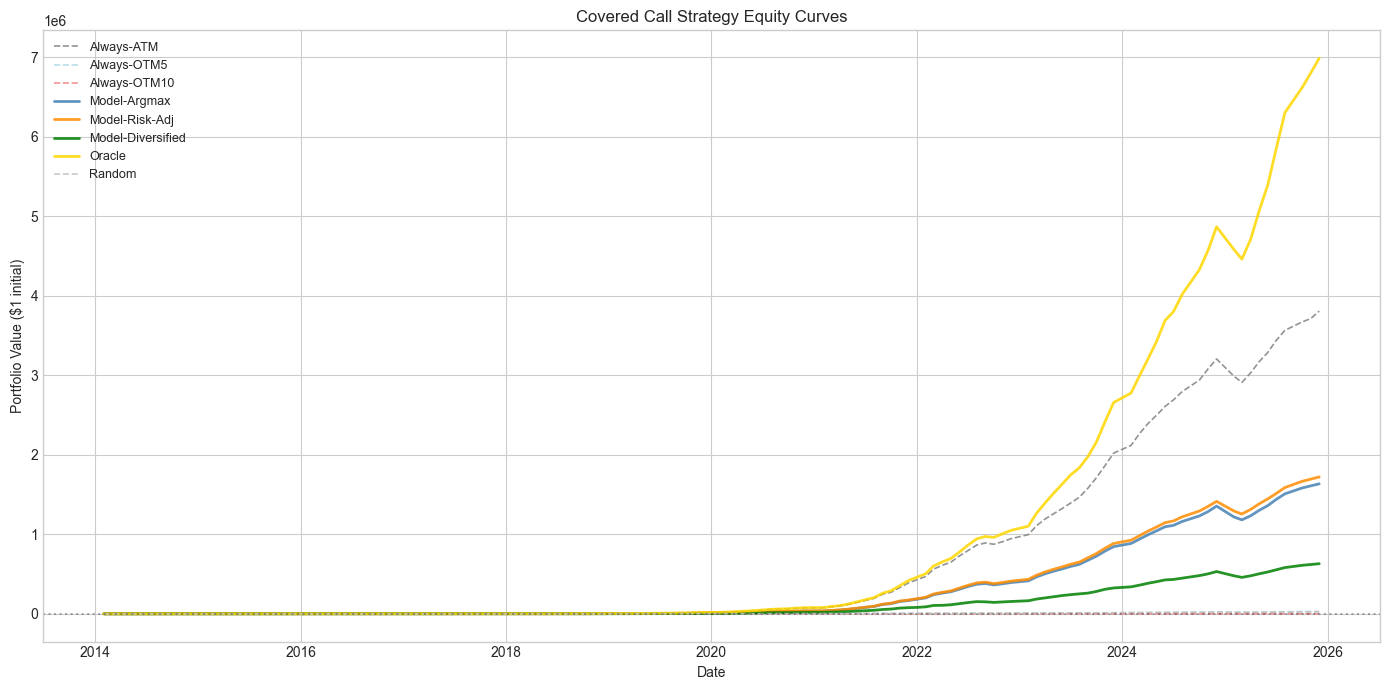

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))

colors = {
    'Always-ATM': 'gray',
    'Always-OTM5': 'lightblue',
    'Always-OTM10': 'lightcoral',
    'Random': 'silver',
    'Model-Argmax': 'steelblue',
    'Model-Risk-Adj': 'darkorange',
    'Model-Diversified': 'green',
    'Oracle': 'gold',
}

for col in strat_cols:
    equity = (1 + portfolio[col]).cumprod()
    style = '--' if col.startswith('Always') or col == 'Random' else '-'
    lw = 1.2 if col.startswith('Always') or col == 'Random' else 2.0
    ax.plot(portfolio['year_month_ts'], equity, label=col,
            color=colors.get(col, 'black'), linestyle=style, linewidth=lw, alpha=0.85)

ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value ($1 initial)')
ax.set_title('Covered Call Strategy Equity Curves')
ax.legend(loc='upper left', fontsize=9)
ax.axhline(y=1, color='black', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Annual Returns

Annual Returns by Strategy:
 Year  Always-ATM  Always-OTM5  Always-OTM10  Model-Argmax  Model-Risk-Adj  Model-Diversified  Oracle  Random
 2014      1.9551       1.0823        0.5460        1.1852          1.1852             1.1852  1.9878  1.3472
 2015      4.0367       1.7325        0.6086        3.2800          3.4442             3.3415  4.0415  1.7090
 2016      3.9434       1.6665        0.7135        3.4808          3.4808             2.9677  3.9434  1.7727
 2017      8.0187       3.4729        1.6109        8.0187          8.0187             6.5137  8.0795  3.5916
 2018      3.0737       1.5039        0.4889        3.0737          3.0737             2.1780  3.0737  1.6973
 2019      5.2596       2.9573        1.2991        5.2596          5.2596             4.3236  5.2499  2.9188
 2020      3.4212       1.5460        0.7324        2.6778          2.6778             2.6778  3.4950  1.2176
 2021      4.1915       1.9437        0.8932        3.6960          3.6960             3.383

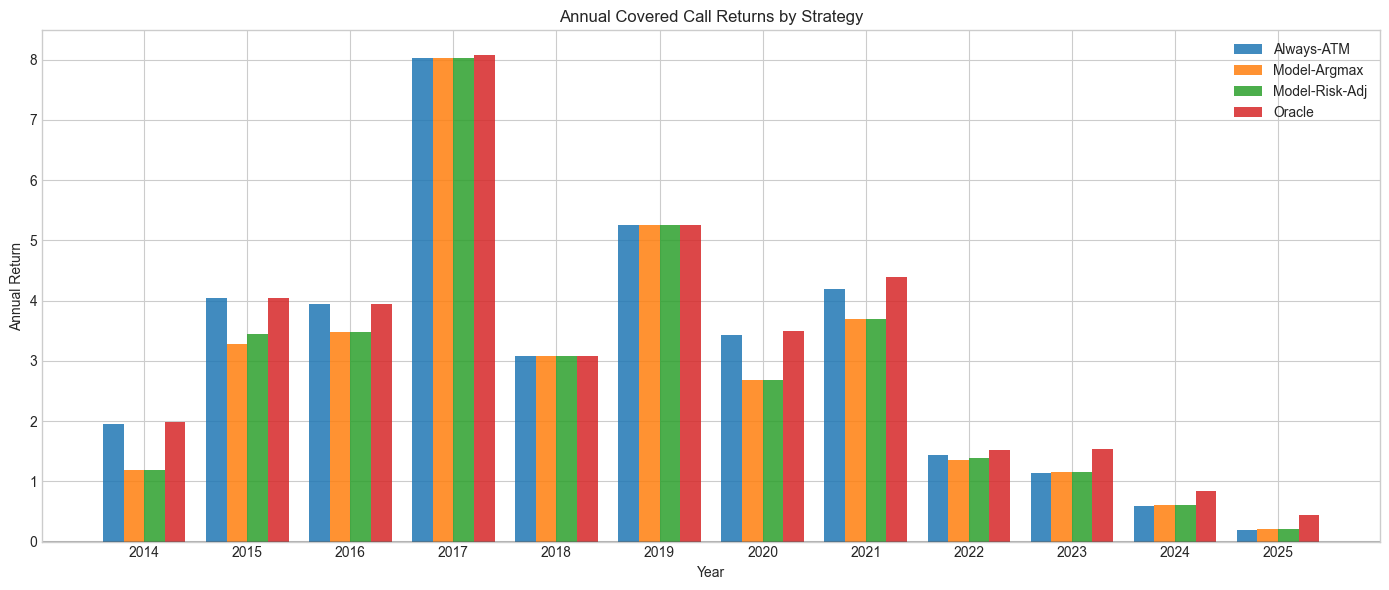

In [10]:
portfolio['year'] = portfolio['year_month_ts'].dt.year

# Annual returns per strategy (geometric)
annual_rows = []
for year in sorted(portfolio['year'].unique()):
    yr_data = portfolio[portfolio['year'] == year]
    row = {'Year': year}
    for col in strat_cols:
        row[col] = (1 + yr_data[col]).prod() - 1
    annual_rows.append(row)

annual_df = pd.DataFrame(annual_rows)
print("Annual Returns by Strategy:")
print(annual_df.round(4).to_string(index=False))

# Bar chart for key strategies
plot_strats = ['Always-ATM', 'Model-Argmax', 'Model-Risk-Adj', 'Oracle']
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(annual_df))
w = 0.2
for i, col in enumerate(plot_strats):
    ax.bar(x + i * w, annual_df[col], w, label=col, alpha=0.85)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(annual_df['Year'].astype(int).values)
ax.set_xlabel('Year')
ax.set_ylabel('Annual Return')
ax.set_title('Annual Covered Call Returns by Strategy')
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'annual_returns_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Per-Ticker Breakdown

Per-Ticker Mean Monthly Return:
        Always-ATM  Model-Argmax  Model-Risk-Adj  Oracle  Alpha (Argmax)  Alpha (Risk-Adj)
symbol                                                                                    
AAPL        0.0916        0.0902          0.0911  0.0972         -0.0014           -0.0005
AMZN        0.0960        0.0939          0.0939  0.1095         -0.0020           -0.0020
AVGO        0.3015        0.2838          0.2829  0.3073         -0.0177           -0.0186
GOOG        0.1918        0.1762          0.1753  0.2031         -0.0156           -0.0165
GOOGL       0.1771        0.1703          0.1703  0.1859         -0.0069           -0.0069
META        0.0260        0.0318          0.0321  0.0439          0.0058            0.0061
MSFT        0.0379        0.0375          0.0376  0.0428         -0.0004           -0.0003
NVDA        0.1797        0.1680          0.1667  0.1947         -0.0117           -0.0130
TSLA        0.0718        0.0526          0.0569  0.0831  

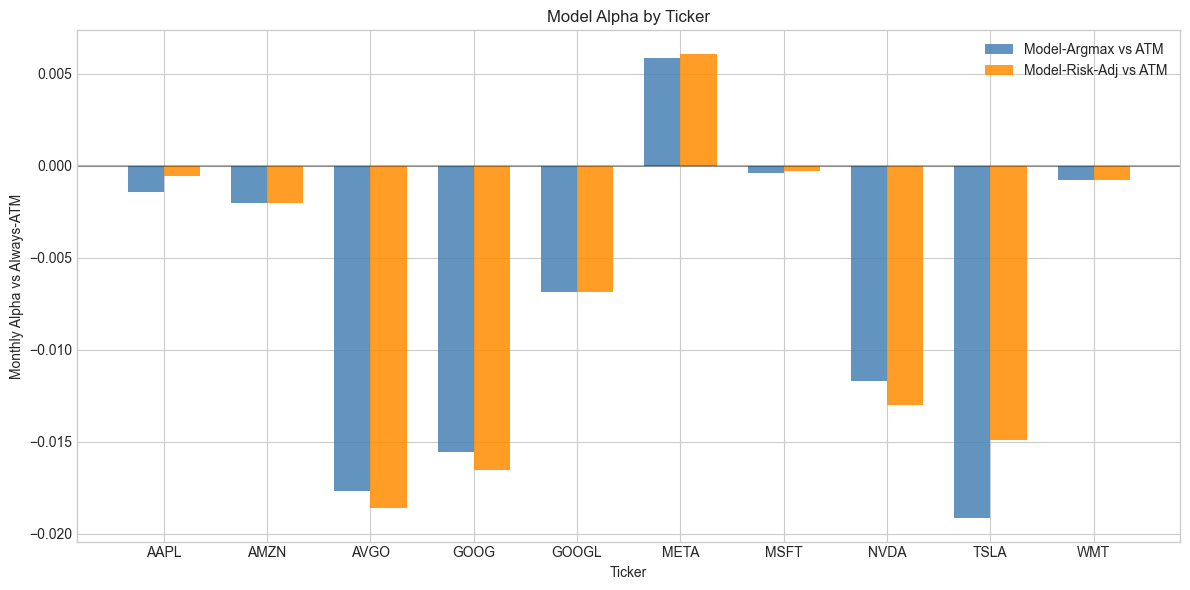

In [11]:
# Per-ticker mean monthly return: model vs always-ATM
ticker_perf = bt.groupby('symbol')[['Always-ATM', 'Model-Argmax', 'Model-Risk-Adj', 'Oracle']].mean()
ticker_perf['Alpha (Argmax)'] = ticker_perf['Model-Argmax'] - ticker_perf['Always-ATM']
ticker_perf['Alpha (Risk-Adj)'] = ticker_perf['Model-Risk-Adj'] - ticker_perf['Always-ATM']

print("Per-Ticker Mean Monthly Return:")
print(ticker_perf.round(4).to_string())

# Alpha bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(ticker_perf))
w = 0.35
ax.bar(x - w/2, ticker_perf['Alpha (Argmax)'], w, label='Model-Argmax vs ATM',
       color='steelblue', alpha=0.85)
ax.bar(x + w/2, ticker_perf['Alpha (Risk-Adj)'], w, label='Model-Risk-Adj vs ATM',
       color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ticker_perf.index)
ax.set_xlabel('Ticker')
ax.set_ylabel('Monthly Alpha vs Always-ATM')
ax.set_title('Model Alpha by Ticker')
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'per_ticker_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Statistical Significance of Model Alpha

In [12]:
# Paired t-test: model monthly returns vs always-ATM
for model_col in ['Model-Argmax', 'Model-Risk-Adj']:
    diff = portfolio[model_col] - portfolio['Always-ATM']
    t_stat, p_val = stats.ttest_rel(portfolio[model_col], portfolio['Always-ATM'])
    mean_diff = diff.mean()
    se = diff.std(ddof=1) / np.sqrt(len(diff))

    print(f"{model_col} vs Always-ATM:")
    print(f"  Mean monthly alpha: {mean_diff:.4f}")
    print(f"  95% CI: [{mean_diff - 1.96*se:.4f}, {mean_diff + 1.96*se:.4f}]")
    print(f"  t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")
    if p_val < 0.05:
        print(f"  Significant at alpha=0.05")
    else:
        print(f"  Not significant at alpha=0.05")

    # Wilcoxon as robustness check
    w_stat, w_pval = stats.wilcoxon(portfolio[model_col], portfolio['Always-ATM'])
    print(f"  Wilcoxon: W={w_stat:.1f}, p={w_pval:.4f}")
    print()

Model-Argmax vs Always-ATM:
  Mean monthly alpha: -0.0074
  95% CI: [-0.0118, -0.0030]
  t-statistic: -3.261, p-value: 0.0014
  Significant at alpha=0.05
  Wilcoxon: W=574.0, p=0.0076

Model-Risk-Adj vs Always-ATM:
  Mean monthly alpha: -0.0070
  95% CI: [-0.0113, -0.0026]
  t-statistic: -3.110, p-value: 0.0023
  Significant at alpha=0.05
  Wilcoxon: W=543.0, p=0.0098



## 12. Conclusion

In [13]:
print("=" * 60)
print("BACKTESTING SUMMARY")
print("=" * 60)
print(f"\nPeriod: {portfolio['year_month_ts'].min().date()} to {portfolio['year_month_ts'].max().date()}")
print(f"Months: {len(portfolio)}")
print(f"Tickers: {bt['symbol'].nunique()}")
print()

# Print the top strategies by Sharpe
print("Top strategies by Sharpe ratio:")
for _, row in metrics_df.head(5).iterrows():
    print(f"  {row['Strategy']:20s}: Sharpe={row['Sharpe']:.3f}, "
          f"Ann.Ret={row['Ann. Return']:.2%}, MaxDD={row['Max DD']:.2%}")

print()
print("Limitations:")
print("  - Transaction costs not modeled (bid-ask spread partially captured via mark price)")
print("  - Monthly rebalancing frequency matches options data granularity")
print("  - No slippage or execution delay modeled")
print("  - Equal-weight portfolio across tickers")

# Save results
metrics_df.to_csv(PROCESSED / 'backtest_results.csv', index=False)
bt.to_csv(PROCESSED / 'backtest_trades.csv', index=False)
print(f"\nSaved: {PROCESSED / 'backtest_results.csv'}")
print(f"Saved: {PROCESSED / 'backtest_trades.csv'}")

BACKTESTING SUMMARY

Period: 2014-02-01 to 2025-12-01
Months: 128
Tickers: 10

Top strategies by Sharpe ratio:
  Oracle              : Sharpe=5.823, Ann.Ret=338.18%, MaxDD=-8.37%
  Always-ATM          : Sharpe=5.363, Ann.Ret=313.93%, MaxDD=-9.20%
  Model-Risk-Adj      : Sharpe=5.068, Ann.Ret=284.24%, MaxDD=-11.27%
  Model-Argmax        : Sharpe=5.047, Ann.Ret=282.40%, MaxDD=-12.71%
  Model-Diversified   : Sharpe=4.896, Ann.Ret=249.69%, MaxDD=-13.81%

Limitations:
  - Transaction costs not modeled (bid-ask spread partially captured via mark price)
  - Monthly rebalancing frequency matches options data granularity
  - No slippage or execution delay modeled
  - Equal-weight portfolio across tickers

Saved: ../data/processed/backtest_results.csv
Saved: ../data/processed/backtest_trades.csv
